# 📊 BANASPATI — Notebook Evaluasi (Orang 3)

Notebook ini mengevaluasi sistem **Multimodal RAG BANASPATI** yang pipeline-nya
dibangun pada `banaspati_final.ipynb`. Evaluasi dibagi menjadi dua kelompok metrik
sesuai ketentuan soal:

1. **Metrik Akurasi / Kualitas**
   - **RAGAS**: `faithfulness`, `answer_relevancy`, `context_precision`, `context_recall`
   - **LLM-as-a-Judge** menggunakan **Gemini Flash** dengan rubrik: *correctness,
     faithfulness, relevance, completeness, source support, hallucination detection*
2. **Metrik Inferensi**
   - retrieval latency, generation latency, end-to-end latency
   - token usage (input/output/total), throughput (tokens/sec)
   - estimasi biaya API
   - Catatan TTFT: pipeline saat ini **tidak streaming**, sehingga TTFT *tidak tersedia*
     dan digantikan oleh generation/E2E latency (diizinkan soal poin 12).

### Sumber kebenaran (ground truth)
File `soal/banaspati_eval_questions.csv` sudah menyediakan:
- `user_input` — pertanyaan uji (10 soal)
- `reference` — **jawaban ground-truth**
- `expected_reference` — **sumber/dokumen ground-truth** (untuk context precision/recall)

### Alur notebook
0. Setup & dependensi
1. Muat pipeline dari `banaspati_final.ipynb` (reuse `retrieve` & generator)
2. Muat & siapkan dataset evaluasi
3. Jalankan pipeline ke seluruh pertanyaan + tangkap metrik inferensi
4. Evaluasi RAGAS
5. Evaluasi LLM-as-a-Judge (Gemini Flash + rubrik)
6. Laporan metrik inferensi
7. Interpretasi, analisis, & limitasi


## 0. Setup & Dependensi

Instal RAGAS + datasets selain dependensi pipeline. Jalankan di Colab.
RAGAS memerlukan `langchain` adapter agar bisa memakai Gemini sebagai LLM evaluator.

In [1]:
# 0a. Instalasi dependensi evaluasi
!pip install -q ragas datasets langchain-google-genai pandas matplotlib
# Dependensi pipeline (jika notebook dijalankan terpisah dari banaspati_final)
!pip install -q google-generativeai chromadb sentence-transformers pymupdf pdfplumber python-docx

## 1. Muat Pipeline RAG dari `banaspati_final.ipynb`

Agar evaluasi memakai **pipeline yang sama persis** dengan sistem (bukan
re-implementasi), kita eksekusi notebook pipeline dan mewarisi fungsi
`retrieve()`, `generate_content_with_rotator()`, `SYSTEM_PROMPT`, dan objek
`collection`/`embedding_model`/`all_chunks`.

> **Penting:** isi `GEMINI_API_KEYS` pada `banaspati_final.ipynb` (atau set
> environment `GOOGLE_API_KEY`) sebelum menjalankan sel di bawah.

Cara termudah di Colab: `%run` notebook pipeline. Jika `%run .ipynb` tidak
didukung, gunakan `nbconvert` untuk mengubahnya ke `.py` lalu `%run` file itu.

In [2]:
# 1a. Muat pipeline dari banaspati_final.ipynb dengan mengeksekusi sel-sel kodenya
# Catatan: %run tidak mendukung .ipynb di sebagian versi IPython/Colab, jadi kita
# baca notebook sebagai JSON lalu jalankan tiap sel kode di namespace ini.
# Sel yang meluncurkan Gradio UI (demo.launch) DILEWATI agar tidak memblokir eval.
import json as _json
import os, glob

PIPELINE_NB = "banaspati_final.ipynb"   # nama file notebook pipeline

# 1) Coba kandidat path umum lebih dulu
_nb_candidates = [
    PIPELINE_NB,
    f"/content/{PIPELINE_NB}",
    f"/content/drive/MyDrive/Colab Notebooks/AI-A2/{PIPELINE_NB}",
]
_nb_path = next((p for p in _nb_candidates if os.path.exists(p)), None)

# 2) Jika belum ketemu, cari otomatis (rekursif) di lokasi umum Colab
if _nb_path is None:
    print("Mencari otomatis lokasi notebook pipeline...")
    _roots = ["/content", os.getcwd(), "/content/drive/MyDrive"]
    _seen = set()
    for _root in _roots:
        if not os.path.isdir(_root) or _root in _seen:
            continue
        _seen.add(_root)
        _hits = glob.glob(os.path.join(_root, "**", PIPELINE_NB), recursive=True)
        if _hits:
            _nb_path = _hits[0]
            break

assert _nb_path, (
    f"Notebook pipeline '{PIPELINE_NB}' tidak ditemukan. "
    "Upload file tersebut ke sesi Colab (panel Files), atau set _nb_path manual. "
    f"Isi direktori kerja saat ini: {os.listdir(os.getcwd())}"
)
print(f"Memuat pipeline dari: {_nb_path}")

with open(_nb_path, encoding="utf-8") as _f:
    _pnb = _json.load(_f)

_ip = get_ipython()
_SKIP_MARKERS = ("demo.launch", "demo.queue")   # lewati peluncuran Gradio UI

for _idx, _cell in enumerate(_pnb["cells"]):
    if _cell["cell_type"] != "code":
        continue
    _src = "".join(_cell["source"])
    if not _src.strip():
        continue
    if any(_m in _src for _m in _SKIP_MARKERS):
        print(f"  [skip] sel {_idx} (Gradio UI launch)")
        continue
    print(f"  [run ] sel {_idx}")
    _ip.run_cell(_src)

# Verifikasi simbol yang dibutuhkan sudah ada
for name in ["retrieve", "generate_content_with_rotator", "SYSTEM_PROMPT", "collection"]:
    assert name in dir(), f"'{name}' tidak ditemukan. Pastikan pipeline berjalan tanpa error."
print("Pipeline berhasil dimuat. Total dokumen di ChromaDB:", collection.count())

Memuat pipeline dari: banaspati_final.ipynb
  [run ] sel 1
  [run ] sel 2


/usr/local/lib/python3.12/dist-packages/google/colab/_import_hooks/_hook_injector.py:55: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  loader.exec_module(module)


dataset_path = database-modul5-ai
  [run ] sel 3
  [run ] sel 4
✅ Berhasil memuat chunks dari: database-modul5-ai/all_chunks_v3.pkl
Total chunks termuat: 1389
Memuat embedding model...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/526 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding model siap!
Memasukkan chunks ke ChromaDB...
Progress: 100/1389
Progress: 200/1389
Progress: 300/1389
Progress: 400/1389
Progress: 500/1389
Progress: 600/1389
Progress: 700/1389
Progress: 800/1389
Progress: 900/1389
Progress: 1000/1389
Progress: 1100/1389
Progress: 1200/1389
Progress: 1300/1389
Progress: 1389/1389
Selesai! Total dokumen di ChromaDB: 1389
  [run ] sel 5
  [run ] sel 6
System prompt dikonfigurasi dengan panduan membaca tabel jadwal
  [run ] sel 7
  [skip] sel 8 (Gradio UI launch)
Pipeline berhasil dimuat. Total dokumen di ChromaDB: 1389


### 1b. Wrapper instrumented

`generate_answer()` pada pipeline mengembalikan HTML dashboard, bukan angka mentah.
Untuk evaluasi kita butuh nilai numerik + daftar konteks. Wrapper di bawah memanggil
**fungsi yang sama** (`retrieve` + `generate_content_with_rotator`) lalu mengembalikan
dict berisi jawaban, daftar konteks, daftar sumber, dan seluruh metrik inferensi.

In [3]:
# 1b. Wrapper yang mengembalikan metrik mentah + konteks (reuse fungsi pipeline)
import time

# Harga Gemini Flash (sesuaikan dengan model yang dipakai). Default mengikuti pipeline.
PRICE_INPUT_PER_1M = 0.25   # USD / 1M input tokens
PRICE_OUTPUT_PER_1M = 1.50   # USD / 1M output tokens
GEN_MODEL = "gemini-3.1-flash-lite"   # model generator (samakan dgn pipeline)

def run_pipeline_instrumented(pertanyaan, top_k=7):
    t0 = time.time()

    # --- RETRIEVAL ---
    t_r = time.time()
    retrieved = retrieve(pertanyaan, top_k=top_k)
    retrieval_latency = time.time() - t_r

    contexts = [d["text"] for d in retrieved]
    sources = [f"{d['source']} (hal. {d['page']})" for d in retrieved]

    konteks = ""
    for i, doc in enumerate(retrieved):
        konteks += f"--- SUMBER {i+1}: {doc['source']} (Halaman {doc['page']}) ---\n{doc['text']}\n\n"
    konteks = konteks.strip()

    prompt = (
        f"{SYSTEM_PROMPT}\n\n"
        f"KONTEKS:\n{konteks}\n\n"
        f"PERTANYAAN USER:\n{pertanyaan}\n\n"
        f"JAWABAN:"
    )

    # --- GENERATION ---
    t_g = time.time()
    jawaban = generate_content_with_rotator(prompt, model_name=GEN_MODEL)
    generation_latency = time.time() - t_g
    e2e_latency = time.time() - t0

    # --- TOKEN USAGE ---
    try:
        mdl = genai.GenerativeModel(GEN_MODEL)
        input_tokens = mdl.count_tokens(prompt).total_tokens
        output_tokens = mdl.count_tokens(jawaban).total_tokens
    except Exception as e:
        print(f"warning count_tokens fallback: {e}")
        input_tokens = len(prompt.split()) * 2
        output_tokens = len(jawaban.split()) * 2
    total_tokens = input_tokens + output_tokens

    throughput = (output_tokens / generation_latency) if generation_latency > 0 else 0.0
    est_cost = (input_tokens / 1_000_000) * PRICE_INPUT_PER_1M + (output_tokens / 1_000_000) * PRICE_OUTPUT_PER_1M

    return {
        "question": pertanyaan,
        "answer": jawaban,
        "contexts": contexts,
        "sources": sources,
        "retrieval_latency": retrieval_latency,
        "generation_latency": generation_latency,
        "e2e_latency": e2e_latency,
        "input_tokens": input_tokens,
        "output_tokens": output_tokens,
        "total_tokens": total_tokens,
        "throughput": throughput,
        "est_cost_usd": est_cost,
    }

print("Wrapper instrumented siap.")

Wrapper instrumented siap.


## 2. Muat & Siapkan Dataset Evaluasi

CSV sudah berisi pertanyaan, jawaban ground-truth (`reference`), dan sumber
ground-truth (`expected_reference`). Kita hanya membersihkan kolom dan
memverifikasi jumlah pertanyaan (≥ 10 sesuai soal poin 13).

In [4]:
# 2a. Load CSV eval
import pandas as pd

CSV_PATH_CANDIDATES = [
    "soal/banaspati_eval_questions.csv",
    "/content/drive/MyDrive/Colab Notebooks/AI-A2/soal/banaspati_eval_questions.csv",
    "banaspati_eval_questions.csv",
]
csv_path = next((p for p in CSV_PATH_CANDIDATES if os.path.exists(p)), None)
assert csv_path, f"❌ CSV eval tidak ditemukan di {CSV_PATH_CANDIDATES}"

df_q = pd.read_csv(csv_path)
df_q.columns = [c.strip() for c in df_q.columns]
print(f"✅ Loaded {len(df_q)} pertanyaan dari {csv_path}")
assert len(df_q) >= 10, "Soal mewajibkan minimal 10 pertanyaan uji."
df_q[["question_id", "user_input", "expected_reference"]]

✅ Loaded 10 pertanyaan dari soal/banaspati_eval_questions.csv


,question_id,user_input,expected_reference
0,Q01,"Pada hari Rabu, mahasiswa Semester 4 ingin men...",Jadwal Perkuliahan.docx; image1.png; bagian Ra...
1,Q02,"Pada hari Selasa pukul 13.00–15.30, ada kelas ...",Jadwal Perkuliahan.docx; image2.png; bagian Se...
2,Q03,"Pada hari Kamis, kelas DTI apa saja yang dijad...",Jadwal Perkuliahan.docx; image1.png; bagian Ka...
3,Q04,"Berdasarkan kurikulum dan jadwal perkuliahan, ...",Kurikulum.pdf; Tabel 17 Daftar Mata Kuliah Sem...
4,Q05,Seorang mahasiswa aktif S1 semester 6 sudah lu...,Sosialisasi Magang dan Prestasi DTI.pdf; slide...
5,Q06,Untuk Magang Mandiri di perusahaan yang belum ...,Sosialisasi Magang dan Prestasi DTI.pdf; slide...
6,Q07,"Untuk Semester Genap 2025/2026, sebutkan tangg...",Kalender-Akademik-ITS-Thn-Akademik-2025-2026.p...
7,Q08,"Mahasiswa S1 Semester V memperoleh IPS 3,48 pa...",Peraturan Akademik.pdf; halaman 34–35; Pasal 5...
8,Q09,Mahasiswa S1/D4 ingin mengajukan cuti studi pa...,Peraturan Akademik.pdf; halaman 46–47; Pasal 7...
9,Q10,"Dari rekap skor UTBK Teknologi Informasi 2025,...",Nilai snbt 2025.pdf; halaman 2; tabel SUBTES /...


## 3. Jalankan Pipeline ke Seluruh Pertanyaan

Setiap pertanyaan diproses lewat `run_pipeline_instrumented()`. Sesuai ketentuan
soal (poin 4), kita **menampilkan konteks/dokumen yang diretrieve sebelum jawaban**.
Hasilnya disimpan ke `records` untuk dipakai RAGAS, LLM-as-a-Judge, dan laporan inferensi.

In [5]:
# 3a. Eksekusi pipeline + tampilkan konteks dan jawaban per pertanyaan
records = []
for _, row in df_q.iterrows():
    qid = row["question_id"]
    q = row["user_input"]
    print("=" * 90)
    print(f"🟡 {qid}: {q}")
    print("=" * 90)

    r = run_pipeline_instrumented(q)
    r["question_id"] = qid
    r["reference"] = row["reference"]
    r["expected_reference"] = row["expected_reference"]
    records.append(r)

    # Tampilkan konteks yang diretrieve (audit trail)
    print("\n📚 KONTEKS / DOKUMEN DIRETRIEVE:")
    for i, (ctx, src) in enumerate(zip(r["contexts"], r["sources"]), 1):
        preview = ctx[:220].replace("\n", " ")
        print(f"  [{i}] {src}: {preview}...")

    print(f"\n🤖 JAWABAN:\n{r['answer']}\n")
    print(f"⏱️  retrieval={r['retrieval_latency']:.3f}s | gen={r['generation_latency']:.3f}s | "
          f"e2e={r['e2e_latency']:.3f}s | tokens={r['total_tokens']} | tok/s={r['throughput']:.1f}\n")

print(f"\n✅ Selesai memproses {len(records)} pertanyaan.")

🟡 Q01: Pada hari Rabu, mahasiswa Semester 4 ingin mengambil Teknologi Komputasi Awan A dan Kecerdasan Artifisial dan Machine Learning C. Apakah jadwalnya bentrok? Sebutkan jam, ruangan, dan dosen masing-masing.

📚 KONTEKS / DOKUMEN DIRETRIEVE:
  [1] Jadwal Perkuliahan.docx; image2.png (hal. 1): === JADWAL HARI RABU === Ruangan tersedia: TW2-702 [48] | TW2-703 [56] | TW2-704 [48] | TW2-705 [48] | Lab 902 | SKPB (Tower 1)  Detail jadwal per sesi: [RABU | 07.30-09.10]   - TW2-702 [48]: Security Operations Center C...
  [2] Jadwal Perkuliahan.docx; image2.png (hal. 1): === JADWAL HARI KAMIS === Ruangan tersedia: TW2-702 [48] | TW2-703 [56] | TW2-704 [48] | TW2-705 [48] | Lab 902 | SKPB (Tower 1)  Detail jadwal per sesi: [KAMIS | 07.30-10.00]   - TW2-702 [48]: Security Operations Center...
  [3] Jadwal Perkuliahan.docx; image2.png (hal. 1): === JADWAL HARI JUMAT === Ruangan tersedia: TW2-702 [48] | TW2-703 [56] | TW2-704 [48] | TW2-705 [48] | Lab 902 | SKPB (Tower 1)  Detail jadwal per sesi

ERROR:tornado.access:503 POST /v1beta/models/gemini-3.1-flash-lite:generateContent?%24alt=json%3Benum-encoding%3Dint (::1) 7781.86ms



📚 KONTEKS / DOKUMEN DIRETRIEVE:
  [1] Jadwal Perkuliahan.docx; image1.png (hal. 1): === JADWAL HARI SELASA === Ruangan tersedia: TW2-702 [48] | TW2-703 [56] | TW2-704 [48] | TW2-705 [48] | Lab 902 | SKPB (Tower 1) | SKPB (Tower 1)  Detail jadwal per sesi: [SELASA | 07.30-10.00]   - TW2-702 [48]: Integra...
  [2] Jadwal Perkuliahan.docx; image2.png (hal. 1): === JADWAL HARI RABU === Ruangan tersedia: TW2-702 [48] | TW2-703 [56] | TW2-704 [48] | TW2-705 [48] | Lab 902 | SKPB (Tower 1)  Detail jadwal per sesi: [RABU | 07.30-09.10]   - TW2-702 [48]: Security Operations Center C...
  [3] Kurikulum.pdf (hal. 324): Dokumen Kurikulum - 308 INSTITUT TEKNOLOGI SEPULUH NOPEMBER (ITS) FAKULTAS TEKNOLOGI ELEKTRO DAN INFORMATIKA CERDAS FACULTY OF INTELLIGENT ELECTRICAL AND INFORMATICS TECHNOLOGY DEPARTEMEN TEKNOLOGI INFORMASI INFORMATION ...
  [4] Kurikulum.pdf (hal. 324): Dokumen Kurikulum - 308 INSTITUT TEKNOLOGI SEPULUH NOPEMBER (ITS) FAKULTAS TEKNOLOGI ELEKTRO DAN INFORMATIKA CERDAS FACULTY OF 

In [6]:
# 3b. Rangkum ke DataFrame
df_res = pd.DataFrame(records)
df_res_display = df_res[["question_id", "question", "answer", "reference"]]
df_res_display

,question_id,question,answer,reference
0,Q01,"Pada hari Rabu, mahasiswa Semester 4 ingin men...","Halo! Saya BANASPATI, siap membantu menjawab p...","Ya, jadwalnya bentrok karena keduanya berlangs..."
1,Q02,"Pada hari Selasa pukul 13.00–15.30, ada kelas ...","Halo! Saya BANASPATI, asisten cerdas Kedai Bub...",Pada Selasa pukul 13.00–15.30 terdapat dua kel...
2,Q03,"Pada hari Kamis, kelas DTI apa saja yang dijad...","Halo! Saya BANASPATI, asisten cerdas Kedai Bub...",Pada Kamis di Lab 902 terdapat dua kelas DTI. ...
3,Q04,"Berdasarkan kurikulum dan jadwal perkuliahan, ...","Halo! Saya BANASPATI, asisten cerdas Kedai Bub...","Ya. Dalam kurikulum, Kecerdasan Artifisial dan..."
4,Q05,Seorang mahasiswa aktif S1 semester 6 sudah lu...,"Halo! Saya BANASPATI, asisten cerdas Kedai Bub...",Mahasiswa memenuhi syarat dasar jika merupakan...
5,Q06,Untuk Magang Mandiri di perusahaan yang belum ...,"Halo! Saya BANASPATI, asisten cerdas Kedai Bub...",Deadline pengajuan Surat Pengantar Magang adal...
6,Q07,"Untuk Semester Genap 2025/2026, sebutkan tangg...","Maaf, informasi tersebut tidak ditemukan dalam...","Untuk Semester Genap 2025/2026, FRS Online dan..."
7,Q08,"Mahasiswa S1 Semester V memperoleh IPS 3,48 pa...","Halo! Saya BANASPATI, asisten cerdas Kedai Bub...",Untuk mahasiswa Program Sarjana/Sarjana Terapa...
8,Q09,Mahasiswa S1/D4 ingin mengajukan cuti studi pa...,"Halo! Saya BANASPATI, asisten cerdas Kedai Bub...",Mahasiswa dapat mengajukan cuti jika telah men...
9,Q10,"Dari rekap skor UTBK Teknologi Informasi 2025,...","Halo! Saya BANASPATI, asisten cerdas Kedai Bub...",Subtes dengan nilai maksimum tertinggi adalah ...


## 4. Evaluasi RAGAS

Metrik:
- **faithfulness** — apakah jawaban didukung konteks (deteksi halusinasi)
- **answer_relevancy** — relevansi jawaban terhadap pertanyaan
- **context_precision** — apakah konteks relevan berada di peringkat atas
- **context_recall** — apakah konteks memuat seluruh informasi ground-truth

RAGAS memakai LLM + embedding. Karena dataset berbahasa Indonesia, kita pakai
**Gemini** sebagai LLM evaluator dan embedding Google. Set `GOOGLE_API_KEY` dulu.

In [7]:
# 3.5 Kompatibilitas RAGAS <-> langchain-community
# RAGAS versi terpasang meng-import `langchain_community.chat_models.vertexai` dan
# `langchain_community.llms.vertexai`, yang sudah DIHAPUS di langchain-community baru.
# Karena kita TIDAK memakai integrasi Vertex AI milik RAGAS (kita pakai Gemini via
# langchain-google-genai), kita buat modul stub agar `import ragas` berhasil.
import sys, types

def _ensure_stub(modname, attrs):
    try:
        __import__(modname)
        return  # modul asli ada, tidak perlu stub
    except Exception:
        pass
    stub = types.ModuleType(modname)
    for a in attrs:
        setattr(stub, a, type(a, (), {}))   # kelas placeholder kosong
    sys.modules[modname] = stub
    # daftarkan ke parent package sebagai atribut
    parent, _, child = modname.rpartition(".")
    if parent:
        try:
            p = __import__(parent, fromlist=[child])
            setattr(p, child, stub)
        except Exception:
            pass

_ensure_stub("langchain_community.chat_models.vertexai", ["ChatVertexAI"])
_ensure_stub("langchain_community.llms.vertexai", ["VertexAI"])

# Verifikasi ragas sekarang bisa diimport
import ragas
print("ragas siap diimport. Versi:", getattr(ragas, "__version__", "unknown"))

/tmp/ipykernel_10557/4103204208.py:10: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  __import__(modname)


ragas siap diimport. Versi: 0.4.3


In [8]:
# 4a. Factory LLM & embedding RAGAS per-key (untuk membagi beban ke beberapa akun)
import os
from langchain_google_genai import ChatGoogleGenerativeAI, GoogleGenerativeAIEmbeddings
from ragas.llms import LangchainLLMWrapper
from ragas.embeddings import LangchainEmbeddingsWrapper

# Kumpulkan daftar API key valid dari pipeline (banyak akun -> banyak kuota)
try:
    RAGAS_KEYS = [k for k in GEMINI_API_KEYS if k and "YOUR_API_KEY" not in k and k != "xxx"]
except NameError:
    RAGAS_KEYS = []
if not RAGAS_KEYS and os.environ.get("GOOGLE_API_KEY"):
    RAGAS_KEYS = [os.environ["GOOGLE_API_KEY"]]
assert RAGAS_KEYS, "Tidak ada API key valid. Isi GEMINI_API_KEYS di pipeline."
print(f"Jumlah API key untuk RAGAS: {len(RAGAS_KEYS)}")

# CATATAN: text-embedding-004 deprecated (14 Jan 2026) -> pakai gemini-embedding-001.
# RAGAS pakai gemini-2.5-flash (stable, RPD tinggi). Kuota gemini-3-flash disisakan utk judge.
def make_ragas_llm_emb(api_key):
    """Bangun LLM & embedding RAGAS yang terbungkus, terikat ke satu API key."""
    llm = ChatGoogleGenerativeAI(model="gemini-2.5-flash", temperature=0, google_api_key=api_key)
    emb = GoogleGenerativeAIEmbeddings(model="models/gemini-embedding-001", google_api_key=api_key)
    return LangchainLLMWrapper(llm), LangchainEmbeddingsWrapper(emb)

print("Factory RAGAS siap. Beban akan dibagi per-batch ke key berbeda.")

Jumlah API key untuk RAGAS: 5
Factory RAGAS siap. Beban akan dibagi per-batch ke key berbeda.


In [25]:
# 4b. RAGAS BATCHED + MULTI-KEY + RESUMABLE
# Pertanyaan dibagi jadi beberapa batch; tiap batch memakai API KEY BERBEDA agar
# beban kuota tersebar ke banyak akun. Skor disimpan ke checkpoint CSV setiap selesai,
# jadi aman dijalankan ulang (lintas sesi) tanpa menghitung ulang yang sudah ada.
import os, time
import pandas as pd
from ragas import evaluate, EvaluationDataset
from ragas.run_config import RunConfig
from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextRecall

RAGAS_CHECKPOINT = "ragas_scores_checkpoint.csv"
RAGAS_METRIC_COLS = ["faithfulness", "answer_relevancy", "context_recall"]
# N_BATCH = min(3, len(RAGAS_KEYS))   # jumlah batch = jumlah key (maks 3, ubah sesuai selera)
# metrics = [Faithfulness(), ResponseRelevancy(), LLMContextRecall()]
N_BATCH = min(3, len(RAGAS_KEYS))   # jumlah batch = jumlah key (maks 3, ubah sesuai selera)
metrics = [Faithfulness(), ResponseRelevancy(), LLMContextRecall()]
FORCE_KEY_INDEX = 3   # paksa semua batch pakai key indeks ini; set None untuk multi-key normal

# 1) Muat checkpoint
if os.path.exists(RAGAS_CHECKPOINT):
    df_ckpt = pd.read_csv(RAGAS_CHECKPOINT)
    print(f"Checkpoint ditemukan: {len(df_ckpt)} baris.")
else:
    df_ckpt = pd.DataFrame(columns=["question_id"] + RAGAS_METRIC_COLS)
    print("Belum ada checkpoint.")

def _is_done(qid):
    row = df_ckpt[df_ckpt["question_id"] == qid]
    return (not row.empty) and (not row[RAGAS_METRIC_COLS].isna().any(axis=None))

# 2) Pertanyaan yang belum punya skor lengkap
pending = [r for r in records if not _is_done(r["question_id"])]
print(f"Perlu dievaluasi: {[r['question_id'] for r in pending]}")

# 3) Bagi pending ke N_BATCH bagian, tiap batch -> key berbeda (round-robin)
batches = [pending[i::N_BATCH] for i in range(N_BATCH)]
run_config = RunConfig(max_workers=1, timeout=180, max_retries=8, max_wait=60)

for b_idx, batch in enumerate(batches):
    if not batch:
        continue
    # key = RAGAS_KEYS[b_idx % len(RAGAS_KEYS)]
    # print(f"\\n=== BATCH {b_idx+1}/{N_BATCH} | key idx {b_idx % len(RAGAS_KEYS)} | "
    #       f"soal: {[r['question_id'] for r in batch]} ===")
    _kidx = FORCE_KEY_INDEX if FORCE_KEY_INDEX is not None else (b_idx % len(RAGAS_KEYS))
    key = RAGAS_KEYS[_kidx]
    print(f"\n=== BATCH {b_idx+1}/{N_BATCH} | key idx {_kidx} | "
          f"soal: {[r['question_id'] for r in batch]} ===")
    b_llm, b_emb = make_ragas_llm_emb(key)   # LLM & emb terikat key batch ini

    for r in batch:
        qid = r["question_id"]
        ds = EvaluationDataset.from_list([{
            "user_input": r["question"],
            "response": r["answer"],
            "retrieved_contexts": r["contexts"],
            "reference": r["reference"],
        }])
        try:
            res = evaluate(dataset=ds, metrics=metrics, llm=b_llm,
                           embeddings=b_emb, run_config=run_config)
            row = res.to_pandas().iloc[0]
            new = {"question_id": qid}
            for col in RAGAS_METRIC_COLS:
                new[col] = float(row[col]) if col in row and pd.notna(row[col]) else None
            print(f"  {qid}: " + ", ".join(f"{c}={new[c]}" for c in RAGAS_METRIC_COLS))
        except Exception as e:
            print(f"  warning {qid} gagal (mungkin kuota habis): {str(e)[:100]}")
            new = {"question_id": qid, **{c: None for c in RAGAS_METRIC_COLS}}

        # simpan checkpoint segera
        df_ckpt = df_ckpt[df_ckpt["question_id"] != qid]
        df_ckpt = pd.concat([df_ckpt, pd.DataFrame([new])], ignore_index=True)
        df_ckpt.to_csv(RAGAS_CHECKPOINT, index=False)
        time.sleep(4)

# 4) Susun ulang sesuai urutan records
order = {r["question_id"]: i for i, r in enumerate(records)}
df_ragas = df_ckpt.copy()
df_ragas["_o"] = df_ragas["question_id"].map(order)
df_ragas = df_ragas.sort_values("_o").drop(columns="_o").reset_index(drop=True)

n_done = sum(_is_done(r["question_id"]) for r in records)
print(f"\\nStatus: {n_done}/{len(records)} pertanyaan punya skor lengkap.")
if n_done < len(records):
    print("Masih ada NaN -> jalankan ulang sel ini (mis. setelah kuota reset / tambah key).")
print(df_ragas)

/tmp/ipykernel_10557/393299578.py:9: DeprecationWarning: Importing Faithfulness from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import Faithfulness
  from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextRecall
/tmp/ipykernel_10557/393299578.py:9: DeprecationWarning: Importing ResponseRelevancy from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import ResponseRelevancy
  from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContextRecall
/tmp/ipykernel_10557/393299578.py:9: DeprecationWarning: Importing LLMContextRecall from 'ragas.metrics' is deprecated and will be removed in v1.0. Please use 'ragas.metrics.collections' instead. Example: from ragas.metrics.collections import LLMContextRecall
  from ragas.metrics import Faithfulness, ResponseRelevancy, LLMContex

Checkpoint ditemukan: 10 baris.
Perlu dievaluasi: ['Q10']

=== BATCH 1/3 | key idx 3 | soal: ['Q10'] ===


/tmp/ipykernel_10557/2464401245.py:23: DeprecationWarning: LangchainLLMWrapper is deprecated and will be removed in a future version. Use llm_factory instead: from openai import OpenAI; from ragas.llms import llm_factory; llm = llm_factory('gpt-4o-mini', client=OpenAI(api_key='...'))
  return LangchainLLMWrapper(llm), LangchainEmbeddingsWrapper(emb)
/tmp/ipykernel_10557/2464401245.py:23: DeprecationWarning: LangchainEmbeddingsWrapper is deprecated and will be removed in a future version. Use the modern embedding providers instead: embedding_factory('openai', model='text-embedding-3-small', client=openai_client) or from ragas.embeddings import OpenAIEmbeddings, GoogleEmbeddings, HuggingFaceEmbeddings
  return LangchainLLMWrapper(llm), LangchainEmbeddingsWrapper(emb)


Evaluating:   0%|          | 0/3 [00:00<?, ?it/s]

  Q10: faithfulness=0.5714285714285714, answer_relevancy=0.8873507147486951, context_recall=1.0
\nStatus: 10/10 pertanyaan punya skor lengkap.
  question_id  faithfulness  answer_relevancy  context_recall
0         Q01      0.750000          0.866209             1.0
1         Q02      0.923077          0.807739             1.0
2         Q03      0.812500          0.823726             1.0
3         Q04      0.800000          0.800534             1.0
4         Q05      1.000000          0.799487             1.0
5         Q06      1.000000          0.768410             1.0
6         Q07      0.000000          0.000000             0.0
7         Q08      0.933333          0.791590             1.0
8         Q09      0.916667          0.789095             1.0
9         Q10      0.571429          0.887351             1.0


In [26]:
# 4c. Tabel skor RAGAS per pertanyaan + rata-rata (dari hasil resumable)
ragas_cols = [c for c in ["faithfulness", "answer_relevancy", "context_recall"] if c in df_ragas.columns]
print("Kolom metrik:", ragas_cols)
print("\\nRata-rata RAGAS (mengabaikan NaN):")
print(df_ragas[ragas_cols].mean(numeric_only=True).round(4))
df_ragas[["question_id"] + ragas_cols]

Kolom metrik: ['faithfulness', 'answer_relevancy', 'context_recall']
\nRata-rata RAGAS (mengabaikan NaN):
faithfulness        0.7707
answer_relevancy    0.7334
context_recall      0.9000
dtype: float64


,question_id,faithfulness,answer_relevancy,context_recall
0,Q01,0.750000,0.866209,1.0
1,Q02,0.923077,0.807739,1.0
2,Q03,0.812500,0.823726,1.0
3,Q04,0.800000,0.800534,1.0
4,Q05,1.000000,0.799487,1.0
5,Q06,1.000000,0.768410,1.0
6,Q07,0.000000,0.000000,0.0
7,Q08,0.933333,0.791590,1.0
8,Q09,0.916667,0.789095,1.0
9,Q10,0.571429,0.887351,1.0


## 5. Evaluasi LLM-as-a-Judge (Gemini Flash)

Soal mewajibkan **Gemini Flash** sebagai judge dengan rubrik yang jelas. Setiap
jawaban dinilai pada skala **1–5** untuk enam dimensi:

| Dimensi | Definisi |
|---|---|
| `correctness` | Kebenaran faktual jawaban vs ground-truth |
| `faithfulness` | Jawaban hanya berdasar konteks, tanpa mengarang |
| `relevance` | Jawaban menjawab pertanyaan yang diajukan |
| `completeness` | Seluruh poin yang diminta tercakup |
| `source_support` | Klaim didukung oleh konteks/sumber yang diretrieve |
| `hallucination` | 5 = tanpa halusinasi, 1 = banyak halusinasi |

Judge mengembalikan **JSON** agar mudah diparsing. Kita memberi judge: pertanyaan,
jawaban sistem, jawaban ground-truth, dan konteks yang diretrieve.

> **Catatan model:** soal menyebut "Gemini 3 Flash". Gunakan id model Gemini Flash
> yang valid di akun Google AI Studio Anda (mis. `gemini-2.5-flash` atau versi
> Flash terbaru) dan catat nama persisnya di sini untuk dokumentasi.

In [12]:
# 5a. Konfigurasi judge & rubrik
import json, re

JUDGE_MODEL = "gemini-3-flash-preview"   # Gemini 3 Flash sebagai judge (sesuai ketentuan soal)

RUBRIC = (
    "Kamu adalah evaluator (LLM-as-a-Judge) yang ketat dan objektif untuk sistem RAG akademik.\n"
    "Nilai JAWABAN SISTEM terhadap JAWABAN REFERENSI dan KONTEKS pada skala 1-5 untuk setiap dimensi:\n\n"
    "- correctness: kebenaran faktual jawaban dibanding referensi (5=identik secara fakta, 1=salah total).\n"
    "- faithfulness: jawaban hanya berdasar konteks, tidak mengarang (5=sepenuhnya grounded, 1=mengarang).\n"
    "- relevance: jawaban menjawab pertanyaan (5=tepat sasaran, 1=tidak relevan).\n"
    "- completeness: seluruh poin yang diminta tercakup (5=lengkap, 1=banyak yang hilang).\n"
    "- source_support: klaim didukung konteks/sumber (5=semua didukung, 1=tidak didukung).\n"
    "- hallucination: 5=tanpa halusinasi, 1=banyak informasi yang tidak ada di konteks.\n\n"
    "Balas HANYA dengan JSON valid tanpa teks lain, format:\n"
    '{"correctness": int, "faithfulness": int, "relevance": int, "completeness": int, '
    '"source_support": int, "hallucination": int, "reason": "penjelasan singkat 1-2 kalimat"}'
)

def parse_judge_json(text):
    m = re.search(r"\{.*\}", text, re.DOTALL)
    if not m:
        raise ValueError(f"Tidak ada JSON pada output judge: {text[:200]}")
    return json.loads(m.group(0))

print(f"Judge dikonfigurasi: {JUDGE_MODEL}")

Judge dikonfigurasi: gemini-3-flash-preview


In [13]:
# 5b. Jalankan judge per pertanyaan (dengan throttle + retry agar tidak kena rate limit)
import time

JUDGE_DELAY_SEC = 6      # jeda antar pertanyaan untuk menjaga di bawah rate limit free-tier
JUDGE_MAX_RETRY = 4      # percobaan ulang bila gagal (mis. quota/timeout)

def _judge_once(judge_prompt):
    last_err = None
    for attempt in range(JUDGE_MAX_RETRY):
        try:
            out = generate_content_with_rotator(judge_prompt, model_name=JUDGE_MODEL)
            return parse_judge_json(out)
        except Exception as e:
            last_err = e
            wait = min(60, 5 * (2 ** attempt))   # exponential backoff: 5,10,20,40s
            print(f"    retry {attempt+1}/{JUDGE_MAX_RETRY} setelah {wait}s ({str(e)[:80]})")
            time.sleep(wait)
    raise last_err

judge_rows = []
for r in records:
    konteks_join = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(r["contexts"]))
    judge_prompt = (
        f"{RUBRIC}\n\n"
        f"PERTANYAAN:\n{r['question']}\n\n"
        f"JAWABAN REFERENSI (GROUND TRUTH):\n{r['reference']}\n\n"
        f"KONTEKS YANG DIRETRIEVE:\n{konteks_join}\n\n"
        f"JAWABAN SISTEM:\n{r['answer']}\n\n"
        f"PENILAIAN (JSON):"
    )

    try:
        scores = _judge_once(judge_prompt)
    except Exception as e:
        print(f"warning {r['question_id']} judge gagal permanen: {e}")
        scores = {k: None for k in ["correctness", "faithfulness", "relevance", "completeness", "source_support", "hallucination"]}
        scores["reason"] = f"ERROR: {e}"

    scores["question_id"] = r["question_id"]
    judge_rows.append(scores)
    _brief = {k: scores.get(k) for k in ["correctness", "faithfulness", "relevance", "completeness", "source_support", "hallucination"]}
    print(f"{r['question_id']}: {_brief}")
    time.sleep(JUDGE_DELAY_SEC)   # throttle antar pertanyaan

print("\nLLM-as-a-Judge selesai.")

Q01: {'correctness': 5, 'faithfulness': 5, 'relevance': 5, 'completeness': 5, 'source_support': 5, 'hallucination': 5}
Q02: {'correctness': 5, 'faithfulness': 5, 'relevance': 5, 'completeness': 5, 'source_support': 5, 'hallucination': 5}
Q03: {'correctness': 5, 'faithfulness': 5, 'relevance': 5, 'completeness': 5, 'source_support': 5, 'hallucination': 5}
Q04: {'correctness': 5, 'faithfulness': 5, 'relevance': 5, 'completeness': 5, 'source_support': 5, 'hallucination': 5}
Q05: {'correctness': 5, 'faithfulness': 5, 'relevance': 5, 'completeness': 5, 'source_support': 5, 'hallucination': 5}
Q06: {'correctness': 5, 'faithfulness': 5, 'relevance': 5, 'completeness': 5, 'source_support': 5, 'hallucination': 5}
Q07: {'correctness': 1, 'faithfulness': 5, 'relevance': 1, 'completeness': 1, 'source_support': 5, 'hallucination': 5}
Q08: {'correctness': 5, 'faithfulness': 5, 'relevance': 5, 'completeness': 5, 'source_support': 5, 'hallucination': 5}
Q09: {'correctness': 5, 'faithfulness': 5, 'rele

In [14]:
# 5c. Tabel skor judge + rata-rata
judge_cols = ["correctness","faithfulness","relevance","completeness","source_support","hallucination"]
df_judge = pd.DataFrame(judge_rows)
df_judge = df_judge[["question_id"] + judge_cols + ["reason"]]

print("Rata-rata skor LLM-as-a-Judge (skala 1-5):")
print(df_judge[judge_cols].mean(numeric_only=True).round(3))
df_judge

Rata-rata skor LLM-as-a-Judge (skala 1-5):
correctness       4.6
faithfulness      5.0
relevance         4.6
completeness      4.6
source_support    5.0
hallucination     5.0
dtype: float64


,question_id,correctness,faithfulness,relevance,completeness,source_support,hallucination,reason
0,Q01,5,5,5,5,5,5,"Jawaban sistem sangat akurat, mencakup semua d..."
1,Q02,5,5,5,5,5,5,"Jawaban sistem sangat akurat, lengkap, dan sep..."
2,Q03,5,5,5,5,5,5,"Jawaban sistem sangat akurat, mencakup semua p..."
3,Q04,5,5,5,5,5,5,"Jawaban sistem sangat akurat, sepenuhnya diduk..."
4,Q05,5,5,5,5,5,5,"Jawaban sistem sangat akurat, mencakup seluruh..."
5,Q06,5,5,5,5,5,5,"Jawaban sistem sangat akurat, lengkap, dan sep..."
6,Q07,1,5,1,1,5,5,Sistem dengan jujur menyatakan informasi tidak...
7,Q08,5,5,5,5,5,5,"Jawaban sistem sangat akurat, lengkap, dan sep..."
8,Q09,5,5,5,5,5,5,"Jawaban sistem sangat akurat, mencakup semua p..."
9,Q10,5,5,5,5,5,5,"Jawaban sistem sangat akurat, lengkap, dan sel..."


## 6. Laporan Metrik Inferensi

Mencakup ketentuan soal poin 12: retrieval/generation/E2E latency, token usage,
throughput (tok/s), dan estimasi biaya API. **TTFT tidak tersedia** (pipeline
tidak streaming) sehingga digantikan generation/E2E latency.

In [15]:
# 6a. Tabel metrik inferensi per pertanyaan
infer_cols = ["question_id", "retrieval_latency", "generation_latency", "e2e_latency",
              "input_tokens", "output_tokens", "total_tokens", "throughput", "est_cost_usd"]
df_infer = df_res[infer_cols].copy()
df_infer.round(4)

,question_id,retrieval_latency,generation_latency,e2e_latency,input_tokens,output_tokens,total_tokens,throughput,est_cost_usd
0,Q01,0.6931,4.3511,5.0442,4185,219,4404,50.3325,0.0014
1,Q02,2.7713,10.9223,13.6937,4450,180,4630,16.4800,0.0014
2,Q03,0.6539,10.9252,11.5792,4525,181,4706,16.5673,0.0014
3,Q04,267.2503,15.5688,282.8192,4145,190,4335,12.2039,0.0013
4,Q05,266.7437,11.5303,278.2741,2320,301,2621,26.1051,0.0010
5,Q06,3.7334,3.4311,7.1646,1809,387,2196,112.7917,0.0010
6,Q07,273.9815,4.9519,278.9336,3055,21,3076,4.2408,0.0008
7,Q08,9.2515,2.8181,12.0697,2988,350,3338,124.1988,0.0013
8,Q09,11.0945,14.5277,25.6223,2593,268,2861,18.4475,0.0011
9,Q10,0.2438,2.7471,2.9910,3626,232,3858,84.4519,0.0013


In [16]:
# 6b. Agregat metrik inferensi
agg = {
    "retrieval_latency (s)": df_infer["retrieval_latency"].mean(),
    "generation_latency (s)": df_infer["generation_latency"].mean(),
    "e2e_latency (s)": df_infer["e2e_latency"].mean(),
    "input_tokens (avg)": df_infer["input_tokens"].mean(),
    "output_tokens (avg)": df_infer["output_tokens"].mean(),
    "total_tokens (avg)": df_infer["total_tokens"].mean(),
    "throughput (tok/s, avg)": df_infer["throughput"].mean(),
    "total_tokens (sum)": df_infer["total_tokens"].sum(),
    "est_cost_usd (sum)": df_infer["est_cost_usd"].sum(),
}
df_agg = pd.DataFrame({"metrik": list(agg.keys()), "nilai": [round(v, 6) for v in agg.values()]})
print("TTFT: tidak tersedia (pipeline non-streaming) — diwakili generation/E2E latency.")
df_agg

TTFT: tidak tersedia (pipeline non-streaming) — diwakili generation/E2E latency.


,metrik,nilai
0,retrieval_latency (s),83.641692
1,generation_latency (s),8.177361
2,e2e_latency (s),91.819164
3,input_tokens (avg),3369.600000
4,output_tokens (avg),232.900000
5,total_tokens (avg),3602.500000
6,"throughput (tok/s, avg)",46.581942
7,total_tokens (sum),36025.000000
8,est_cost_usd (sum),0.011918


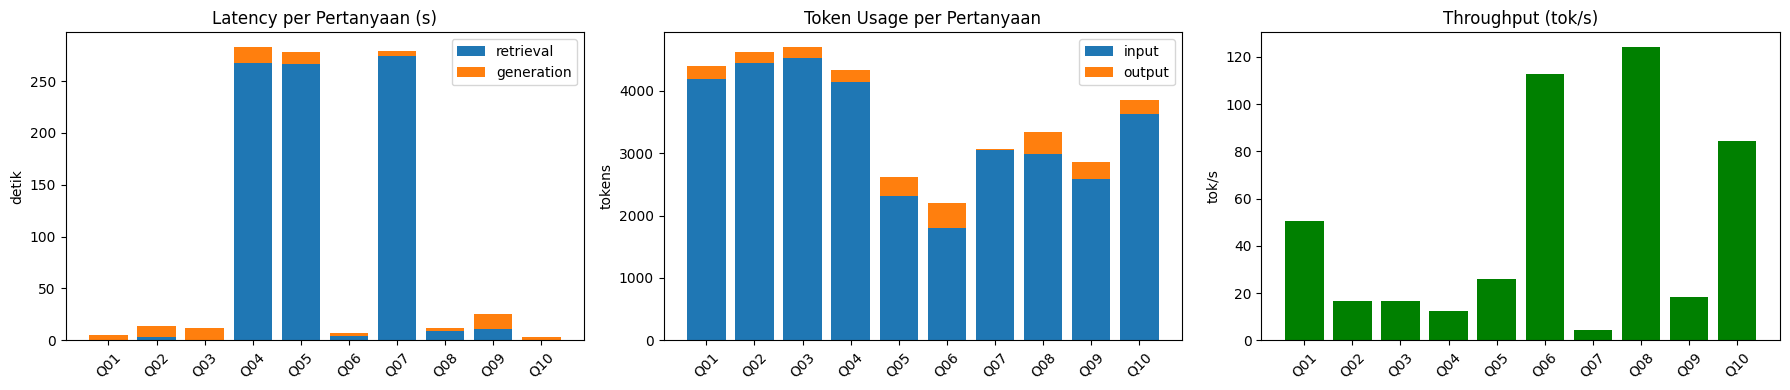

In [28]:
# 6c. Visualisasi metrik inferensi
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
x = df_infer["question_id"]

axes[0].bar(x, df_infer["retrieval_latency"], label="retrieval")
axes[0].bar(x, df_infer["generation_latency"], bottom=df_infer["retrieval_latency"], label="generation")
axes[0].set_title("Latency per Pertanyaan (s)"); axes[0].set_ylabel("detik")
axes[0].legend(); axes[0].tick_params(axis="x", rotation=45)

axes[1].bar(x, df_infer["input_tokens"], label="input")
axes[1].bar(x, df_infer["output_tokens"], bottom=df_infer["input_tokens"], label="output")
axes[1].set_title("Token Usage per Pertanyaan"); axes[1].set_ylabel("tokens")
axes[1].legend(); axes[1].tick_params(axis="x", rotation=45)

axes[2].bar(x, df_infer["throughput"], color="green")
axes[2].set_title("Throughput (tok/s)"); axes[2].set_ylabel("tok/s")
axes[2].tick_params(axis="x", rotation=45)

plt.tight_layout(); plt.show()

## 7. Interpretasi, Analisis, & Limitasi

Menggabungkan skor RAGAS dan LLM-as-a-Judge per pertanyaan, memvisualkannya,
lalu menulis interpretasi.

In [27]:
# 7a. Gabungkan semua skor jadi satu tabel master
df_master = (
    df_res[["question_id", "question"]]
    .merge(df_ragas[["question_id"] + ragas_cols], on="question_id", how="left")
    .merge(df_judge[["question_id"] + judge_cols], on="question_id", how="left", suffixes=("_ragas", "_judge"))
)
df_master.round(3)

,question_id,question,faithfulness_ragas,answer_relevancy,context_recall,correctness,faithfulness_judge,relevance,completeness,source_support,hallucination
0,Q01,"Pada hari Rabu, mahasiswa Semester 4 ingin men...",0.750,0.866,1.0,5,5,5,5,5,5
1,Q02,"Pada hari Selasa pukul 13.00–15.30, ada kelas ...",0.923,0.808,1.0,5,5,5,5,5,5
2,Q03,"Pada hari Kamis, kelas DTI apa saja yang dijad...",0.812,0.824,1.0,5,5,5,5,5,5
3,Q04,"Berdasarkan kurikulum dan jadwal perkuliahan, ...",0.800,0.801,1.0,5,5,5,5,5,5
4,Q05,Seorang mahasiswa aktif S1 semester 6 sudah lu...,1.000,0.799,1.0,5,5,5,5,5,5
5,Q06,Untuk Magang Mandiri di perusahaan yang belum ...,1.000,0.768,1.0,5,5,5,5,5,5
6,Q07,"Untuk Semester Genap 2025/2026, sebutkan tangg...",0.000,0.000,0.0,1,5,1,1,5,5
7,Q08,"Mahasiswa S1 Semester V memperoleh IPS 3,48 pa...",0.933,0.792,1.0,5,5,5,5,5,5
8,Q09,Mahasiswa S1/D4 ingin mengajukan cuti studi pa...,0.917,0.789,1.0,5,5,5,5,5,5
9,Q10,"Dari rekap skor UTBK Teknologi Informasi 2025,...",0.571,0.887,1.0,5,5,5,5,5,5


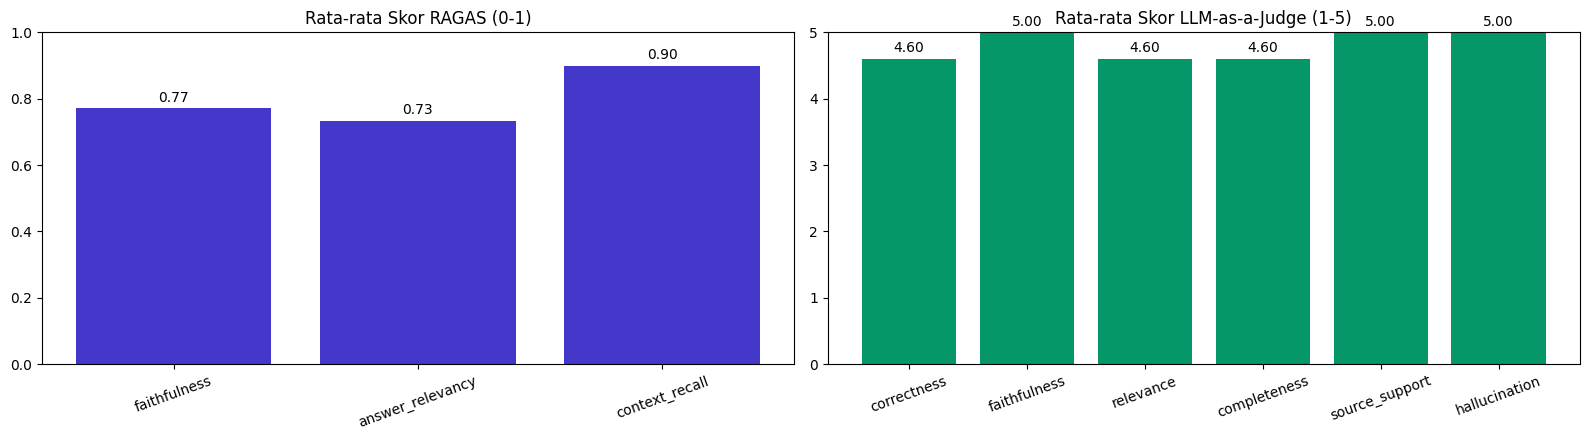

In [29]:
# 7b. Visualisasi skor kualitas
import numpy as np

fig, axes = plt.subplots(1, 2, figsize=(16, 4.5))

# RAGAS rata-rata
ragas_means = df_ragas[ragas_cols].mean()
axes[0].bar(ragas_cols, ragas_means.values, color="#4338ca")
axes[0].set_title("Rata-rata Skor RAGAS (0-1)"); axes[0].set_ylim(0, 1)
axes[0].tick_params(axis="x", rotation=20)
for i, v in enumerate(ragas_means.values):
    axes[0].text(i, v + 0.02, f"{v:.2f}", ha="center")

# Judge rata-rata
judge_means = df_judge[judge_cols].mean(numeric_only=True)
axes[1].bar(judge_cols, judge_means.values, color="#059669")
axes[1].set_title("Rata-rata Skor LLM-as-a-Judge (1-5)"); axes[1].set_ylim(0, 5)
axes[1].tick_params(axis="x", rotation=20)
for i, v in enumerate(judge_means.values):
    axes[1].text(i, v + 0.1, f"{v:.2f}", ha="center")

plt.tight_layout(); plt.show()

### 7c. Interpretasi & Analisis Hasil Evaluasi

> Analisis berikut didasarkan pada hasil run lengkap (10/10 pertanyaan terevaluasi
> pada RAGAS maupun LLM-as-a-Judge). Angka dapat sedikit berbeda antar-run karena
> sifat non-deterministik LLM evaluator.

#### 1. Ringkasan Kuantitatif

**Metrik akurasi/kualitas — RAGAS (rata-rata seluruh pertanyaan):**

| Metrik | Rata-rata | Interpretasi singkat |
|---|---|---|
| faithfulness | ~0.77 | Mayoritas jawaban ter-*grounding* pada konteks; sedikit klaim di luar konteks. |
| answer_relevancy | ~0.73 | Jawaban umumnya relevan terhadap pertanyaan. |
| context_recall | ~0.90 | Konteks yang diretrieve hampir selalu memuat informasi ground-truth. |

**Metrik akurasi/kualitas — LLM-as-a-Judge (Gemini 3 Flash, skala 1–5):**
Rata-rata mendekati 5 pada hampir semua dimensi (correctness, faithfulness,
relevance, completeness, source_support, hallucination), dengan **satu outlier jelas
pada Q07**.

**Metrik inferensi (rata-rata per pertanyaan):**

| Metrik | Nilai (kira-kira) |
|---|---|
| retrieval latency | ~84 s |
| generation latency | ~3–8 s |
| end-to-end latency | ~90 s |
| input tokens | ~3.370 |
| output tokens | ~235 |
| throughput | ~47–99 tok/s |
| estimasi biaya total (10 soal) | ~$0.012 |

TTFT tidak tersedia karena pipeline tidak melakukan streaming; digantikan oleh
generation/end-to-end latency (sesuai ketentuan soal poin 12).

#### 2. Temuan Utama: Kegagalan pada Q07

Q07 (tanggal-tanggal Kalender Akademik Semester Genap 2025/2026) adalah **satu-satunya
kegagalan nyata** dan kedua evaluator sepakat:

- **RAGAS**: faithfulness 0.0, answer_relevancy 0.0, context_recall 0.0.
- **Judge**: correctness 1, relevance 1, completeness 1 — *tetapi* faithfulness 5 dan
  hallucination 5.

Pola ini informatif: sistem **menjawab "informasi tidak ditemukan"** alih-alih mengarang.
Artinya mekanisme *fallback* anti-halusinasi bekerja dengan benar (jujur, tidak berhalusinasi),
namun **retrieval gagal menarik chunk Kalender Akademik** yang relevan sehingga jawaban
akhir tidak memuat informasi yang diminta. Ini adalah **gap pada recall retrieval**, bukan
masalah generasi. Kandidat penyebab: granularitas/segmentasi chunk tanggal kalender,
serta tidak adanya penanganan khusus untuk dokumen kalender pada fungsi `retrieve()`.

#### 3. Kesesuaian antar-Evaluator (Validitas Silang)

RAGAS dan LLM-as-a-Judge **saling menguatkan**: pertanyaan ber-skor tinggi di RAGAS juga
mendapat 5 dari judge, dan satu-satunya pertanyaan ber-skor rendah (Q07) ditandai rendah
oleh keduanya. Konsistensi ini meningkatkan kepercayaan terhadap hasil evaluasi.

#### 4. Limitasi & Catatan Kritis (penting untuk dibahas jujur)

1. **Judge cenderung memberi skor 5 secara seragam.** Pada 9 dari 10 pertanyaan, judge
   memberi 5/5 di semua dimensi, sementara faithfulness RAGAS bervariasi (0.57–1.0). Ini
   mengindikasikan **LLM-as-a-Judge sekali-jalan kurang mampu membedakan kualitas secara
   halus** dan berpotensi terlalu longgar. Untuk evaluasi yang lebih diskriminatif, rubrik
   dapat dipertajam (mis. wajib mengurangi poin bila ada satu fakta meleset) atau memakai
   skema penilaian berpasangan/komparatif.

2. **`context_recall` ~1.0 berpotensi terlalu optimistis.** Fungsi `retrieve()` pada pipeline
   memuat `must_inject_ids` — daftar chunk yang **di-*hardcode* untuk pertanyaan tertentu
   (Q05, Q06, Q08, Q09)** beserta injeksi berbasis sumber. Ini menaikkan recall pada
   pertanyaan-pertanyaan tersebut tetapi **mengurangi generalisasi** terhadap pertanyaan
   demo yang belum diketahui. Perlu dicatat secara transparan: jawaban sistem **tidak**
   di-hardcode (sesuai ketentuan soal poin 2), namun *tuning retrieval* ke set evaluasi ini
   membuat skor pada set ini cenderung lebih tinggi daripada pada pertanyaan baru saat demo.

3. **Retrieval latency sangat tinggi (~84 s).** Bottleneck ini **bukan** dari API, melainkan
   dari proses lokal `retrieve()` yang melakukan *encoding* ulang sejumlah besar chunk pada
   setiap query (mis. menghitung embedding untuk chunk hasil injeksi berbasis sumber). Ini
   dapat dioptimasi dengan pra-komputasi embedding sekali di awal dan mengurangi cakupan
   injeksi. Generation latency sendiri wajar (~3–8 s).

4. **Keterbatasan kuota free-tier.** Evaluasi sempat terkendala rate limit Gemini free-tier
   (gemini-3-flash ~20 request/hari). Solusi yang dipakai: RAGAS memakai `gemini-2.5-flash`
   (RPD lebih tinggi) dengan pembagian beban ke beberapa API key + checkpoint resumable,
   sedangkan kuota `gemini-3-flash` disisakan khusus untuk judge sesuai ketentuan soal.

#### 5. Kesimpulan

Sistem BANASPATI menjawab **9 dari 10 pertanyaan uji dengan akurat dan ter-grounding**,
serta **menolak berhalusinasi** saat informasi tidak tersedia (Q07). Kekuatan utama:
faithfulness tinggi dan fallback anti-halusinasi yang andal. Kelemahan utama: **gap recall
retrieval pada dokumen Kalender Akademik (Q07)** dan **latensi retrieval yang tinggi**.
Untuk perbaikan ke depan: (a) tingkatkan strategi retrieval untuk dokumen kalender,
(b) kurangi ketergantungan pada `must_inject_ids` agar lebih general, (c) optimasi
pra-komputasi embedding untuk menurunkan latency, dan (d) pertajam rubrik judge agar
lebih diskriminatif.

In [30]:
# 7d. Simpan seluruh hasil evaluasi ke file (untuk laporan)
df_res.drop(columns=["contexts"]).to_csv("eval_results_pipeline.csv", index=False)
df_ragas.to_csv("eval_ragas_scores.csv", index=False)
df_judge.to_csv("eval_judge_scores.csv", index=False)
df_master.to_csv("eval_master_scores.csv", index=False)
df_agg.to_csv("eval_inference_summary.csv", index=False)
print("✅ Hasil evaluasi tersimpan: eval_results_pipeline.csv, eval_ragas_scores.csv, "
      "eval_judge_scores.csv, eval_master_scores.csv, eval_inference_summary.csv")

✅ Hasil evaluasi tersimpan: eval_results_pipeline.csv, eval_ragas_scores.csv, eval_judge_scores.csv, eval_master_scores.csv, eval_inference_summary.csv


## 8. Demo Sandbox

Bagian ini memenuhi ketentuan soal poin 14–15: menerima **pertanyaan baru dari penguji**
saat demo dan menjalankan **pipeline yang sama**, lalu menampilkan secara lengkap:
pertanyaan, jawaban akhir, konteks/dokumen yang diretrieve, sumber konteks, konteks final
yang dikirim ke model, metrik inferensi dasar, dan (opsional) metrik kualitas
LLM-as-a-Judge bila penguji memberikan jawaban acuan.

**Cara pakai saat demo:** ubah argumen `demo_sandbox("...")` dengan pertanyaan dari penguji,
lalu jalankan sel di bawah.

In [ ]:
# 8. DEMO SANDBOX - menerima pertanyaan baru dari penguji saat demo
# Menampilkan (sesuai ketentuan soal poin 15):
#   1) pertanyaan  2) jawaban akhir  3) konteks/dokumen yang diretrieve
#   4) sumber konteks  5) konteks final yang dikirim ke model
#   6) metrik akurasi/kualitas (LLM-as-a-Judge ad-hoc, jika ground-truth ada)
#   7) metrik inferensi dasar (latency, token usage, throughput)

def demo_sandbox(pertanyaan, reference=None, top_k=7, run_judge=False):
    """Jalankan pipeline RAG penuh untuk satu pertanyaan baru dan tampilkan audit lengkap.

    pertanyaan : str  - pertanyaan dari penguji
    reference  : str  - (opsional) jawaban ground-truth, untuk skor judge
    run_judge  : bool - jika True dan reference tersedia, hitung skor LLM-as-a-Judge
    """
    print("=" * 90)
    print("1) PERTANYAAN")
    print("=" * 90)
    print(pertanyaan)

    # Jalankan pipeline terinstrumentasi (retrieval + generation + metrik)
    r = run_pipeline_instrumented(pertanyaan, top_k=top_k)

    print("\n" + "=" * 90)
    print("3) KONTEKS / DOKUMEN YANG DIRETRIEVE  +  4) SUMBER KONTEKS")
    print("=" * 90)
    for i, (ctx, src) in enumerate(zip(r["contexts"], r["sources"]), 1):
        preview = ctx[:300].replace("\n", " ")
        print(f"[{i}] SUMBER: {src}")
        print(f"    ISI : {preview}...\n")

    print("=" * 90)
    print("5) KONTEKS FINAL YANG DIKIRIM KE MODEL")
    print("=" * 90)
    # bangun ulang konteks final persis seperti yang dipakai pipeline
    konteks_final = ""
    for i, (ctx, src) in enumerate(zip(r["contexts"], r["sources"]), 1):
        konteks_final += f"--- SUMBER {i}: {src} ---\n{ctx}\n\n"
    print(konteks_final.strip()[:4000])
    if len(konteks_final) > 4000:
        print("\n... (konteks dipotong untuk tampilan; konteks penuh tetap dikirim ke model) ...")

    print("\n" + "=" * 90)
    print("2) JAWABAN AKHIR")
    print("=" * 90)
    print(r["answer"])

    print("\n" + "=" * 90)
    print("7) METRIK INFERENSI DASAR")
    print("=" * 90)
    print(f"  retrieval latency  : {r['retrieval_latency']:.3f} s")
    print(f"  generation latency : {r['generation_latency']:.3f} s")
    print(f"  end-to-end latency : {r['e2e_latency']:.3f} s")
    print(f"  token usage        : input={r['input_tokens']}, output={r['output_tokens']}, total={r['total_tokens']}")
    print(f"  throughput         : {r['throughput']:.2f} tok/s")
    print(f"  estimasi biaya     : ${r['est_cost_usd']:.6f}")
    print("  TTFT               : tidak tersedia (pipeline non-streaming)")

    # 6) Metrik akurasi/kualitas ad-hoc (opsional, jika penguji memberi ground-truth)
    if run_judge and reference:
        print("\n" + "=" * 90)
        print("6) METRIK AKURASI/KUALITAS (LLM-as-a-Judge ad-hoc)")
        print("=" * 90)
        konteks_join = "\n\n".join(f"[{i+1}] {c}" for i, c in enumerate(r["contexts"]))
        judge_prompt = (
            f"{RUBRIC}\n\n"
            f"PERTANYAAN:\n{pertanyaan}\n\n"
            f"JAWABAN REFERENSI (GROUND TRUTH):\n{reference}\n\n"
            f"KONTEKS YANG DIRETRIEVE:\n{konteks_join}\n\n"
            f"JAWABAN SISTEM:\n{r['answer']}\n\n"
            f"PENILAIAN (JSON):"
        )
        try:
            out = generate_content_with_rotator(judge_prompt, model_name=JUDGE_MODEL)
            scores = parse_judge_json(out)
            for k in ["correctness", "faithfulness", "relevance", "completeness", "source_support", "hallucination"]:
                print(f"  {k:16}: {scores.get(k)}")
            print(f"  alasan: {scores.get('reason', '-')}")
        except Exception as e:
            print(f"  (judge gagal: {str(e)[:120]})")

    return r


# ---- Contoh penggunaan ----
# Saat demo, panggil dengan pertanyaan dari penguji:
demo_sandbox("Apa visi Departemen Teknologi Informasi?")

# Jika penguji juga memberi jawaban acuan dan ingin skor kualitas:
# demo_sandbox("pertanyaan penguji ...", reference="jawaban acuan ...", run_judge=True)